# Linear one-hot model for professional match prediction

Train `LinearOneHotDraftModel` on one-hot draft features to classify professional vs public matches, then inspect hero coefficients directly.

In [1]:
import importlib
import json
import sys
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module
import scripts.ml.models.linear_one_hot as linear_one_hot_module

importlib.reload(dataset_module)
importlib.reload(linear_one_hot_module)

DatasetMaker = dataset_module.DatasetMaker
LinearOneHotDraftModel = linear_one_hot_module.LinearOneHotDraftModel

In [22]:
SAMPLES_PER_CLASS = 4_000
BATCH_SIZE = 64
VAL_FRACTION = 0.2
SEED = 42

LR = 3e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 25
THRESHOLD = 0.5

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [23]:
PROFESSIONAL_DRAFTS_QUERY = """
    WITH complete_matches AS (
        SELECT
            m.match_id,
            m.is_professional_match
        FROM dotabuff_matches m
        JOIN dotabuff_match_players p ON p.match_id = m.match_id
        WHERE
            m.is_professional_match IS NOT NULL
            AND p.side IN ('radiant', 'dire')
            AND p.hero_slug IS NOT NULL
        GROUP BY m.match_id, m.is_professional_match
        HAVING
            COUNT(*) = 10
            AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5
            AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5
    ),
    selected_matches AS (
        SELECT match_id, is_professional_match
        FROM (
            SELECT
                match_id,
                is_professional_match,
                ROW_NUMBER() OVER (PARTITION BY is_professional_match ORDER BY match_id DESC) AS class_rank
            FROM complete_matches
        ) ranked
        WHERE class_rank <= %(samples_per_class)s
    )
    SELECT
        m.match_id,
        m.is_professional_match,
        p.side,
        p.hero_slug AS hero,
        p.player_slot
    FROM selected_matches sm
    JOIN dotabuff_matches m ON m.match_id = sm.match_id
    JOIN dotabuff_match_players p ON p.match_id = m.match_id
    ORDER BY m.is_professional_match DESC, m.match_id DESC, p.player_slot ASC
"""


def rows_to_professional_samples(rows, dataset):
    samples = []
    current_match_id = None
    current_is_professional = None
    radiant_heroes = []
    dire_heroes = []

    def flush_current():
        if current_match_id is None:
            return
        if len(radiant_heroes) != 5 or len(dire_heroes) != 5:
            raise ValueError(f"Match {current_match_id} is incomplete after SQL filtering")
        samples.append(
            {
                "match_id": int(current_match_id),
                "radiant_hero_ids": [dataset.hero_name_to_id(hero) for hero in radiant_heroes],
                "dire_hero_ids": [dataset.hero_name_to_id(hero) for hero in dire_heroes],
                "is_professional_match": int(bool(current_is_professional)),
            }
        )

    for row in rows:
        row_match_id = int(row["match_id"])
        if current_match_id is None:
            current_match_id = row_match_id
            current_is_professional = row["is_professional_match"]
        elif row_match_id != current_match_id:
            flush_current()
            current_match_id = row_match_id
            current_is_professional = row["is_professional_match"]
            radiant_heroes = []
            dire_heroes = []

        if row["side"] == "radiant":
            radiant_heroes.append(row["hero"])
        elif row["side"] == "dire":
            dire_heroes.append(row["hero"])

    flush_current()
    return samples

In [24]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(PROFESSIONAL_DRAFTS_QUERY, {"samples_per_class": SAMPLES_PER_CLASS})
        rows = cur.fetchall()
    samples = rows_to_professional_samples(rows, dataset)

class_counts = {
    "professional": sum(sample["is_professional_match"] == 1 for sample in samples),
    "non_professional": sum(sample["is_professional_match"] == 0 for sample in samples),
}

len(samples), class_counts, samples[0]

(4902,
 {'professional': 4000, 'non_professional': 902},
 {'match_id': 8801351171,
  'radiant_hero_ids': [86, 138, 74, 137, 131],
  'dire_hero_ids': [54, 108, 123, 40, 39],
  'is_professional_match': 1})

In [25]:
match_ids = torch.tensor([sample["match_id"] for sample in samples], dtype=torch.long)
radiant_ids = torch.tensor([sample["radiant_hero_ids"] for sample in samples], dtype=torch.long)
dire_ids = torch.tensor([sample["dire_hero_ids"] for sample in samples], dtype=torch.long)

# label=1 means professional match; sigmoid(logit) is P(professional | draft).
labels = torch.tensor([sample["is_professional_match"] for sample in samples], dtype=torch.float32)

positive_rate = labels.mean().item()
radiant_ids.shape, dire_ids.shape, labels.shape, positive_rate

(torch.Size([4902, 5]),
 torch.Size([4902, 5]),
 torch.Size([4902]),
 0.8159934878349304)

In [26]:
def newest_per_class_split(match_ids, radiant_ids, dire_ids, labels, val_fraction):
    train_indices = []
    val_indices = []

    for class_value in (0.0, 1.0):
        class_indices = torch.where(labels == class_value)[0]
        class_match_ids = match_ids[class_indices]
        order = torch.argsort(class_match_ids, descending=True)
        class_indices = class_indices[order]

        class_val_size = max(1, int(len(class_indices) * val_fraction)) if len(class_indices) else 0
        val_indices.append(class_indices[:class_val_size])
        train_indices.append(class_indices[class_val_size:])

    train_indices = torch.cat(train_indices)
    val_indices = torch.cat(val_indices)

    train_order = torch.argsort(match_ids[train_indices], descending=True)
    val_order = torch.argsort(match_ids[val_indices], descending=True)
    return train_indices[train_order], val_indices[val_order]


train_indices, val_indices = newest_per_class_split(match_ids, radiant_ids, dire_ids, labels, VAL_FRACTION)

train_dataset = TensorDataset(
    match_ids[train_indices],
    radiant_ids[train_indices],
    dire_ids[train_indices],
    labels[train_indices],
)
val_dataset = TensorDataset(
    match_ids[val_indices],
    radiant_ids[val_indices],
    dire_ids[val_indices],
    labels[val_indices],
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

train_labels = train_dataset.tensors[-1]
val_labels = val_dataset.tensors[-1]

{
    "split": "newest_per_class_validation",
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "train_match_id_min": int(train_dataset.tensors[0].min().item()),
    "train_match_id_max": int(train_dataset.tensors[0].max().item()),
    "val_match_id_min": int(val_dataset.tensors[0].min().item()),
    "val_match_id_max": int(val_dataset.tensors[0].max().item()),
    "train_professional_count": int(train_labels.sum().item()),
    "train_non_professional_count": int((train_labels == 0).sum().item()),
    "val_professional_count": int(val_labels.sum().item()),
    "val_non_professional_count": int((val_labels == 0).sum().item()),
    "train_professional_rate": train_labels.mean().item(),
    "val_professional_rate": val_labels.mean().item(),
}

{'split': 'newest_per_class_validation',
 'train_size': 3922,
 'val_size': 980,
 'train_match_id_min': 6363898944,
 'train_match_id_max': 8800688775,
 'val_match_id_min': 8721437198,
 'val_match_id_max': 8801351171,
 'train_professional_count': 3200,
 'train_non_professional_count': 722,
 'val_professional_count': 800,
 'val_non_professional_count': 180,
 'train_professional_rate': 0.8159102201461792,
 'val_professional_rate': 0.8163265585899353}

In [27]:
heroes_path = PROJECT_ROOT / "dotaconstants" / "build" / "heroes.json"
heroes = json.loads(heroes_path.read_text(encoding="utf-8"))
num_heroes = max(int(hero["id"]) for hero in heroes.values()) + 1

positive_count = train_labels.sum().item()
negative_count = train_labels.numel() - positive_count
pos_weight = torch.tensor([negative_count / max(positive_count, 1.0)], dtype=torch.float32, device=device)

model = LinearOneHotDraftModel(num_heroes=num_heroes).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

{
    "num_heroes": num_heroes,
    "train_positive_count": int(positive_count),
    "train_negative_count": int(negative_count),
    "pos_weight": pos_weight.item(),
    "model": model,
}

{'num_heroes': 156,
 'train_positive_count': 3200,
 'train_negative_count': 722,
 'pos_weight': 0.22562499344348907,
 'model': LinearOneHotDraftModel(
   (regressor): Linear(in_features=312, out_features=1, bias=True)
 )}

In [28]:
batch_match_ids, batch_radiant_ids, batch_dire_ids, batch_labels = next(iter(train_loader))
batch_radiant_ids = batch_radiant_ids.to(device)
batch_dire_ids = batch_dire_ids.to(device)
batch_labels = batch_labels.to(device)

model.train()
logits = model(batch_radiant_ids, batch_dire_ids)
loss = criterion(logits, batch_labels)
probs = torch.sigmoid(logits)

logits.shape, loss.item(), probs[:5].detach().cpu()

(torch.Size([64]),
 0.32066547870635986,
 tensor([0.4874, 0.4699, 0.4890, 0.4429, 0.5031]))

In [29]:
def binary_metrics_from_counts(tp, tn, fp, fn):
    total = tp + tn + fp + fn
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "accuracy": (tp + tn) / total if total else 0.0,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        loss.backward()
        optimizer.step()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device, *, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_examples = 0
    tp = tn = fp = fn = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        preds = (torch.sigmoid(logits) >= threshold).long()
        labels_long = label_batch.long()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        tp += ((preds == 1) & (labels_long == 1)).sum().item()
        tn += ((preds == 0) & (labels_long == 0)).sum().item()
        fp += ((preds == 1) & (labels_long == 0)).sum().item()
        fn += ((preds == 0) & (labels_long == 1)).sum().item()

    metrics = binary_metrics_from_counts(tp, tn, fp, fn)
    metrics.update({"loss": total_loss / total_examples, "tp": tp, "tn": tn, "fp": fp, "fn": fn})
    return metrics

In [30]:
train_positive_rate = train_labels.mean().item()
val_positive_rate = val_labels.mean().item()
baseline_accuracy = max(val_positive_rate, 1.0 - val_positive_rate)
{
    "all_professional_match_rate": positive_rate,
    "train_professional_match_rate": train_positive_rate,
    "val_professional_match_rate": val_positive_rate,
    "val_majority_class_baseline_accuracy": baseline_accuracy,
}

{'all_professional_match_rate': 0.8159934878349304,
 'train_professional_match_rate': 0.8159102201461792,
 'val_professional_match_rate': 0.8163265585899353,
 'val_majority_class_baseline_accuracy': 0.8163265585899353}

In [31]:
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)
    row = {"epoch": epoch, "train_loss": train_loss, **{f"val_{key}": value for key, value in val_metrics.items()}}
    history.append(row)
    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.3f} "
        f"val_precision={val_metrics['precision']:.3f} "
        f"val_recall={val_metrics['recall']:.3f} "
        f"val_f1={val_metrics['f1']:.3f}"
    )

epoch=01 train_loss=0.2196 val_loss=0.2031 val_accuracy=0.866 val_precision=0.967 val_recall=0.866 val_f1=0.914
epoch=02 train_loss=0.1630 val_loss=0.1713 val_accuracy=0.873 val_precision=0.968 val_recall=0.874 val_f1=0.919
epoch=03 train_loss=0.1296 val_loss=0.1516 val_accuracy=0.865 val_precision=0.974 val_recall=0.858 val_f1=0.912
epoch=04 train_loss=0.1083 val_loss=0.1395 val_accuracy=0.863 val_precision=0.976 val_recall=0.854 val_f1=0.911
epoch=05 train_loss=0.0939 val_loss=0.1313 val_accuracy=0.859 val_precision=0.977 val_recall=0.848 val_f1=0.908
epoch=06 train_loss=0.0837 val_loss=0.1250 val_accuracy=0.860 val_precision=0.978 val_recall=0.848 val_f1=0.908
epoch=07 train_loss=0.0759 val_loss=0.1204 val_accuracy=0.860 val_precision=0.980 val_recall=0.846 val_f1=0.908
epoch=08 train_loss=0.0699 val_loss=0.1169 val_accuracy=0.862 val_precision=0.980 val_recall=0.849 val_f1=0.910
epoch=09 train_loss=0.0651 val_loss=0.1149 val_accuracy=0.858 val_precision=0.980 val_recall=0.844 val_f

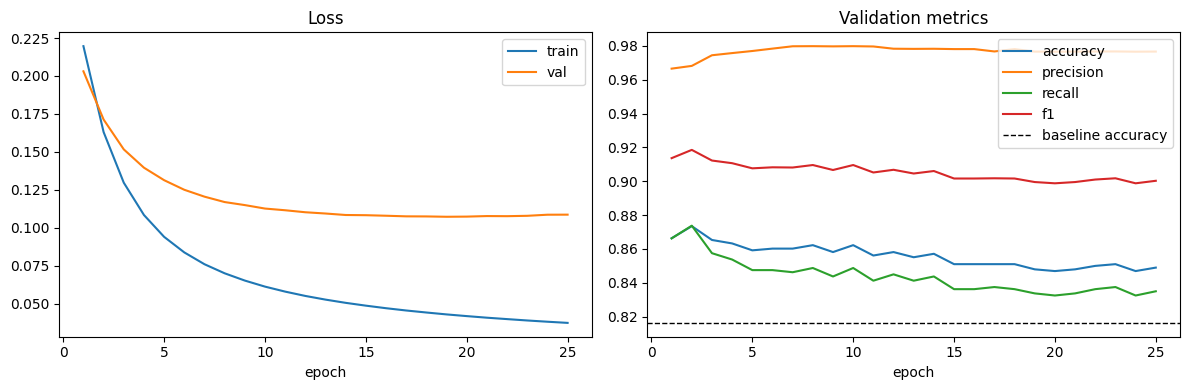

In [32]:
try:
    import matplotlib.pyplot as plt

    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="train")
    axes[0].plot(epochs, [row["val_loss"] for row in history], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, [row["val_accuracy"] for row in history], label="accuracy")
    axes[1].plot(epochs, [row["val_precision"] for row in history], label="precision")
    axes[1].plot(epochs, [row["val_recall"] for row in history], label="recall")
    axes[1].plot(epochs, [row["val_f1"] for row in history], label="f1")
    axes[1].axhline(baseline_accuracy, color="black", linestyle="--", linewidth=1, label="baseline accuracy")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
except ImportError:
    history[-5:]

In [33]:
evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)

{'accuracy': 0.8489795918367347,
 'precision': 0.9766081871345029,
 'recall': 0.835,
 'f1': 0.9002695417789757,
 'loss': 0.10858435232800488,
 'tp': 668,
 'tn': 164,
 'fp': 16,
 'fn': 132}

## Threshold search

Weighted loss can shift calibration. Search a validation threshold that maximizes F1.

In [34]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    rows = []

    for match_id_batch, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        probs = torch.sigmoid(model(radiant_batch, dire_batch)).cpu()

        for match_id, label, probability in zip(match_id_batch.tolist(), label_batch.tolist(), probs.tolist()):
            rows.append(
                {
                    "match_id": int(match_id),
                    "is_professional_match": int(label),
                    "professional_probability": float(probability),
                }
            )

    return rows


val_predictions = collect_predictions(model, val_loader, device)
val_predictions[:5]

[{'match_id': 8801351171,
  'is_professional_match': 1,
  'professional_probability': 0.21860049664974213},
 {'match_id': 8801317432,
  'is_professional_match': 1,
  'professional_probability': 0.6868994832038879},
 {'match_id': 8801213023,
  'is_professional_match': 1,
  'professional_probability': 0.3261711895465851},
 {'match_id': 8801212173,
  'is_professional_match': 1,
  'professional_probability': 0.05989452078938484},
 {'match_id': 8800700540,
  'is_professional_match': 0,
  'professional_probability': 0.5902787446975708}]

In [35]:
def metrics_at_threshold(rows, threshold):
    tp = tn = fp = fn = 0
    for row in rows:
        pred = int(row["professional_probability"] >= threshold)
        label = row["is_professional_match"]
        tp += int(pred == 1 and label == 1)
        tn += int(pred == 0 and label == 0)
        fp += int(pred == 1 and label == 0)
        fn += int(pred == 0 and label == 1)
    metrics = binary_metrics_from_counts(tp, tn, fp, fn)
    metrics.update({"threshold": threshold, "tp": tp, "tn": tn, "fp": fp, "fn": fn})
    return metrics


threshold_rows = [metrics_at_threshold(val_predictions, threshold) for threshold in np.linspace(0.05, 0.95, 19)]
sorted(threshold_rows, key=lambda row: row["f1"], reverse=True)[:10]

[{'accuracy': 0.9275510204081633,
  'precision': 0.9428918590522479,
  'recall': 0.97,
  'f1': 0.9562538508934073,
  'threshold': 0.15,
  'tp': 776,
  'tn': 133,
  'fp': 47,
  'fn': 24},
 {'accuracy': 0.9173469387755102,
  'precision': 0.9454770755885997,
  'recall': 0.95375,
  'f1': 0.9495955196017425,
  'threshold': 0.2,
  'tp': 763,
  'tn': 136,
  'fp': 44,
  'fn': 37},
 {'accuracy': 0.9142857142857143,
  'precision': 0.9241706161137441,
  'recall': 0.975,
  'f1': 0.948905109489051,
  'threshold': 0.1,
  'tp': 780,
  'tn': 116,
  'fp': 64,
  'fn': 20},
 {'accuracy': 0.9091836734693878,
  'precision': 0.9100346020761245,
  'recall': 0.98625,
  'f1': 0.9466106778644271,
  'threshold': 0.05,
  'tp': 789,
  'tn': 102,
  'fp': 78,
  'fn': 11},
 {'accuracy': 0.9122448979591836,
  'precision': 0.9541984732824428,
  'recall': 0.9375,
  'f1': 0.9457755359394704,
  'threshold': 0.25,
  'tp': 750,
  'tn': 144,
  'fp': 36,
  'fn': 50},
 {'accuracy': 0.9,
  'precision': 0.9594240837696335,
  're

## Hero coefficient analysis

This model is linear, so hero-level interpretation is direct: each hero has one coefficient when picked by Radiant and one coefficient when picked by Dire. Larger positive logits mean higher predicted professional-match probability.

In [36]:
def hero_coefficient_rows(model, heroes, radiant_ids, dire_ids, labels):
    weights = model.regressor.weight.detach().cpu().squeeze(0).numpy()
    radiant_weights = weights[: model.num_heroes]
    dire_weights = weights[model.num_heroes :]

    appearances = torch.bincount(
        torch.cat([radiant_ids.flatten(), dire_ids.flatten()]),
        minlength=model.num_heroes,
    ).cpu().numpy()
    professional_appearances = np.zeros(model.num_heroes, dtype=int)

    for radiant_team, dire_team, is_professional in zip(radiant_ids.tolist(), dire_ids.tolist(), labels.long().tolist()):
        if is_professional != 1:
            continue
        for hero_id in radiant_team + dire_team:
            professional_appearances[hero_id] += 1

    rows = []
    for hero in heroes.values():
        hero_id = int(hero["id"])
        if hero_id >= model.num_heroes:
            continue

        localized_name = hero.get("localized_name") or hero.get("name", str(hero_id))
        appearances_count = int(appearances[hero_id])
        professional_count = int(professional_appearances[hero_id])
        radiant_weight = float(radiant_weights[hero_id])
        dire_weight = float(dire_weights[hero_id])
        rows.append(
            {
                "hero_id": hero_id,
                "hero": localized_name,
                "appearances": appearances_count,
                "professional_appearances": professional_count,
                "professional_rate": professional_count / appearances_count if appearances_count else np.nan,
                "radiant_weight": radiant_weight,
                "dire_weight": dire_weight,
                "pro_signal": 0.5 * (radiant_weight + dire_weight),
                "side_gap": dire_weight - radiant_weight,
                "abs_weight_sum": abs(radiant_weight) + abs(dire_weight),
            }
        )

    return rows


hero_rows = hero_coefficient_rows(model, heroes, radiant_ids, dire_ids, labels)
valid_hero_rows = [row for row in hero_rows if row["appearances"] > 0]
valid_hero_rows[:5]

[{'hero_id': 1,
  'hero': 'Anti-Mage',
  'appearances': 166,
  'professional_appearances': 60,
  'professional_rate': 0.3614457831325301,
  'radiant_weight': -0.9698765277862549,
  'dire_weight': -0.9710816144943237,
  'pro_signal': -0.9704790711402893,
  'side_gap': -0.0012050867080688477,
  'abs_weight_sum': 1.9409581422805786},
 {'hero_id': 2,
  'hero': 'Axe',
  'appearances': 569,
  'professional_appearances': 404,
  'professional_rate': 0.7100175746924429,
  'radiant_weight': -0.58685702085495,
  'dire_weight': -0.2685866355895996,
  'pro_signal': -0.4277218282222748,
  'side_gap': 0.31827038526535034,
  'abs_weight_sum': 0.8554436564445496},
 {'hero_id': 3,
  'hero': 'Bane',
  'appearances': 387,
  'professional_appearances': 372,
  'professional_rate': 0.9612403100775194,
  'radiant_weight': 1.4245842695236206,
  'dire_weight': 1.0594791173934937,
  'pro_signal': 1.2420316934585571,
  'side_gap': -0.36510515213012695,
  'abs_weight_sum': 2.4840633869171143},
 {'hero_id': 4,
  'h

In [37]:
MIN_APPEARANCES = 25
frequent_hero_rows = [row for row in valid_hero_rows if row["appearances"] >= MIN_APPEARANCES]

sorted(frequent_hero_rows, key=lambda row: row["pro_signal"], reverse=True)[:20]

[{'hero_id': 66,
  'hero': 'Chen',
  'appearances': 370,
  'professional_appearances': 362,
  'professional_rate': 0.9783783783783784,
  'radiant_weight': 1.117153286933899,
  'dire_weight': 1.6706085205078125,
  'pro_signal': 1.3938809037208557,
  'side_gap': 0.5534552335739136,
  'abs_weight_sum': 2.7877618074417114},
 {'hero_id': 55,
  'hero': 'Dark Seer',
  'appearances': 321,
  'professional_appearances': 306,
  'professional_rate': 0.9532710280373832,
  'radiant_weight': 1.2179055213928223,
  'dire_weight': 1.470895767211914,
  'pro_signal': 1.3444006443023682,
  'side_gap': 0.2529902458190918,
  'abs_weight_sum': 2.6888012886047363},
 {'hero_id': 78,
  'hero': 'Brewmaster',
  'appearances': 311,
  'professional_appearances': 299,
  'professional_rate': 0.9614147909967846,
  'radiant_weight': 1.4636590480804443,
  'dire_weight': 1.1148335933685303,
  'pro_signal': 1.2892463207244873,
  'side_gap': -0.34882545471191406,
  'abs_weight_sum': 2.5784926414489746},
 {'hero_id': 98,
  '

In [38]:
sorted(frequent_hero_rows, key=lambda row: row["pro_signal"])[:20]

[{'hero_id': 30,
  'hero': 'Witch Doctor',
  'appearances': 189,
  'professional_appearances': 26,
  'professional_rate': 0.13756613756613756,
  'radiant_weight': -1.4314550161361694,
  'dire_weight': -1.3286371231079102,
  'pro_signal': -1.3800460696220398,
  'side_gap': 0.10281789302825928,
  'abs_weight_sum': 2.7600921392440796},
 {'hero_id': 14,
  'hero': 'Pudge',
  'appearances': 388,
  'professional_appearances': 149,
  'professional_rate': 0.38402061855670105,
  'radiant_weight': -1.2488423585891724,
  'dire_weight': -1.114928126335144,
  'pro_signal': -1.1818852424621582,
  'side_gap': 0.13391423225402832,
  'abs_weight_sum': 2.3637704849243164},
 {'hero_id': 104,
  'hero': 'Legion Commander',
  'appearances': 140,
  'professional_appearances': 20,
  'professional_rate': 0.14285714285714285,
  'radiant_weight': -0.955862283706665,
  'dire_weight': -1.368183970451355,
  'pro_signal': -1.16202312707901,
  'side_gap': -0.41232168674468994,
  'abs_weight_sum': 2.32404625415802},
 {

In [39]:
sorted(frequent_hero_rows, key=lambda row: abs(row["side_gap"]), reverse=True)[:20]

[{'hero_id': 77,
  'hero': 'Lycan',
  'appearances': 221,
  'professional_appearances': 202,
  'professional_rate': 0.9140271493212669,
  'radiant_weight': 1.5588476657867432,
  'dire_weight': 0.6903702616691589,
  'pro_signal': 1.124608963727951,
  'side_gap': -0.8684774041175842,
  'abs_weight_sum': 2.249217927455902},
 {'hero_id': 45,
  'hero': 'Pugna',
  'appearances': 413,
  'professional_appearances': 381,
  'professional_rate': 0.9225181598062954,
  'radiant_weight': 0.35419994592666626,
  'dire_weight': 1.115647554397583,
  'pro_signal': 0.7349237501621246,
  'side_gap': 0.7614476084709167,
  'abs_weight_sum': 1.4698475003242493},
 {'hero_id': 102,
  'hero': 'Abaddon',
  'appearances': 468,
  'professional_appearances': 445,
  'professional_rate': 0.9508547008547008,
  'radiant_weight': 1.3829582929611206,
  'dire_weight': 0.6460418105125427,
  'pro_signal': 1.0145000517368317,
  'side_gap': -0.7369164824485779,
  'abs_weight_sum': 2.0290001034736633},
 {'hero_id': 90,
  'hero'

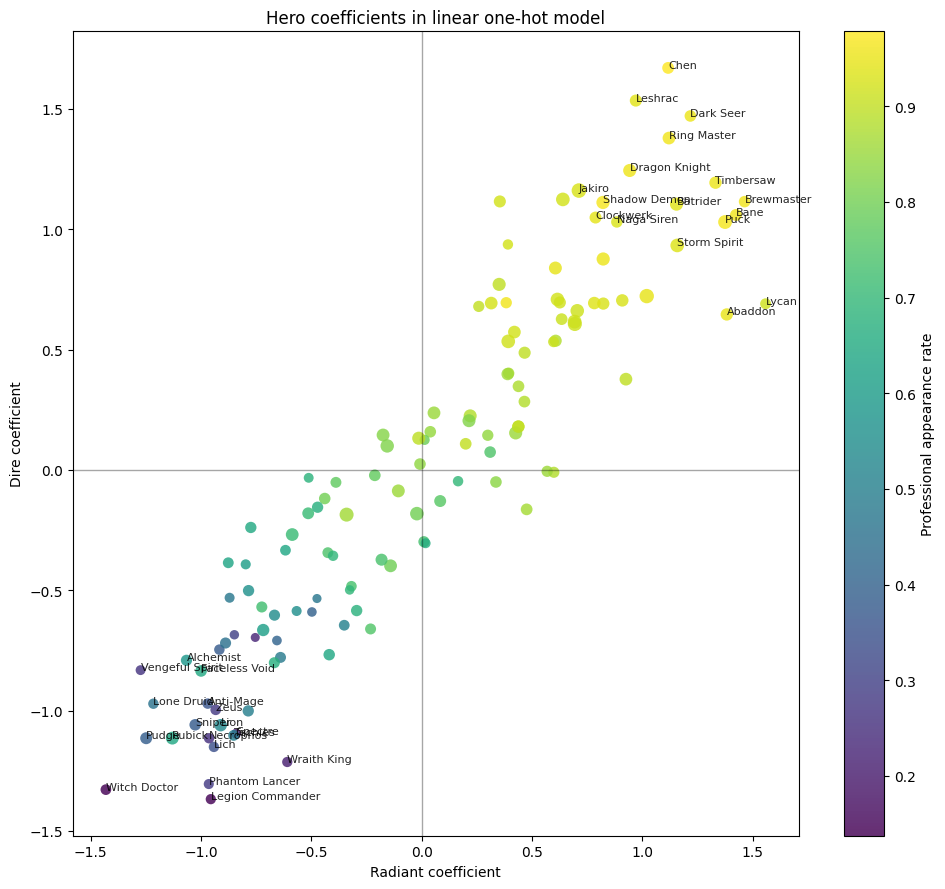

In [40]:
try:
    import matplotlib.pyplot as plt

    xs = [row["radiant_weight"] for row in frequent_hero_rows]
    ys = [row["dire_weight"] for row in frequent_hero_rows]
    colors = [row["professional_rate"] for row in frequent_hero_rows]
    sizes = [25 + 2.5 * np.sqrt(row["appearances"]) for row in frequent_hero_rows]

    fig, ax = plt.subplots(figsize=(10, 9))
    scatter = ax.scatter(xs, ys, c=colors, s=sizes, cmap="viridis", alpha=0.82, edgecolors="none")
    fig.colorbar(scatter, ax=ax, label="Professional appearance rate")
    ax.axhline(0, color="black", linewidth=1, alpha=0.35)
    ax.axvline(0, color="black", linewidth=1, alpha=0.35)

    for row in sorted(frequent_hero_rows, key=lambda item: item["abs_weight_sum"], reverse=True)[:35]:
        ax.annotate(row["hero"], (row["radiant_weight"], row["dire_weight"]), fontsize=8, alpha=0.85)

    ax.set_title("Hero coefficients in linear one-hot model")
    ax.set_xlabel("Radiant coefficient")
    ax.set_ylabel("Dire coefficient")
    plt.tight_layout()
except ImportError:
    frequent_hero_rows[:10]

In [41]:
coefficient_vectors = np.array([[row["radiant_weight"], row["dire_weight"]] for row in frequent_hero_rows])
coefficient_norms = np.clip(np.linalg.norm(coefficient_vectors, axis=1, keepdims=True), 1e-12, None)
normalized_coefficients = coefficient_vectors / coefficient_norms
cosine_similarity = normalized_coefficients @ normalized_coefficients.T
hero_names = [row["hero"] for row in frequent_hero_rows]


def nearest_heroes(hero_name, top_n=8):
    matches = [idx for idx, row in enumerate(frequent_hero_rows) if row["hero"].casefold() == hero_name.casefold()]
    if not matches:
        raise KeyError(f"Unknown hero name or too few appearances: {hero_name!r}")

    row_position = matches[0]
    order = np.argsort(-cosine_similarity[row_position])
    order = [idx for idx in order if idx != row_position][:top_n]
    return [
        {
            "hero": hero_names[idx],
            "cosine_similarity": float(cosine_similarity[row_position, idx]),
            "pro_signal": frequent_hero_rows[idx]["pro_signal"],
            "professional_rate": frequent_hero_rows[idx]["professional_rate"],
            "appearances": frequent_hero_rows[idx]["appearances"],
        }
        for idx in order
    ]


def farthest_heroes(hero_name, top_n=8):
    matches = [idx for idx, row in enumerate(frequent_hero_rows) if row["hero"].casefold() == hero_name.casefold()]
    if not matches:
        raise KeyError(f"Unknown hero name or too few appearances: {hero_name!r}")

    row_position = matches[0]
    order = np.argsort(cosine_similarity[row_position])[:top_n]
    return [
        {
            "hero": hero_names[idx],
            "cosine_similarity": float(cosine_similarity[row_position, idx]),
            "pro_signal": frequent_hero_rows[idx]["pro_signal"],
            "professional_rate": frequent_hero_rows[idx]["professional_rate"],
            "appearances": frequent_hero_rows[idx]["appearances"],
        }
        for idx in order
    ]


nearest_heroes("Pudge")

[{'hero': 'Oracle',
  'cosine_similarity': 0.9999964949820227,
  'pro_signal': -0.37929707765579224,
  'professional_rate': 0.6923076923076923,
  'appearances': 156},
 {'hero': 'Phantom Assassin',
  'cosine_similarity': 0.9999784874180266,
  'pro_signal': -0.6354013681411743,
  'professional_rate': 0.5421686746987951,
  'appearances': 249},
 {'hero': 'Arc Warden',
  'cosine_similarity': 0.9998636609687952,
  'pro_signal': -0.7253020107746124,
  'professional_rate': 0.22916666666666666,
  'appearances': 48},
 {'hero': 'Invoker',
  'cosine_similarity': 0.999833327341052,
  'pro_signal': -0.6918778121471405,
  'professional_rate': 0.6099137931034483,
  'appearances': 464},
 {'hero': 'Witch Doctor',
  'cosine_similarity': 0.9998126414356278,
  'pro_signal': -1.3800460696220398,
  'professional_rate': 0.13756613756613756,
  'appearances': 189},
 {'hero': 'Faceless Void',
  'cosine_similarity': 0.9994616625729446,
  'pro_signal': -0.9176986515522003,
  'professional_rate': 0.6459627329192547

In [42]:
farthest_heroes("Pudge")

[{'hero': 'Troll Warlord',
  'cosine_similarity': -0.9999995718558624,
  'pro_signal': 0.5650622546672821,
  'professional_rate': 0.9095238095238095,
  'appearances': 210},
 {'hero': 'Timbersaw',
  'cosine_similarity': -0.999998105305879,
  'pro_signal': 1.2627010941505432,
  'professional_rate': 0.9542619542619543,
  'appearances': 481},
 {'hero': 'Ember Spirit',
  'cosine_similarity': -0.9999980354766117,
  'pro_signal': 0.6546861529350281,
  'professional_rate': 0.913953488372093,
  'appearances': 860},
 {'hero': 'Void Spirit',
  'cosine_similarity': -0.999993770560306,
  'pro_signal': 0.7378056645393372,
  'professional_rate': 0.9368836291913215,
  'appearances': 507},
 {'hero': 'Doom',
  'cosine_similarity': -0.9999883239063349,
  'pro_signal': 0.5719975531101227,
  'professional_rate': 0.8807339449541285,
  'appearances': 436},
 {'hero': 'Tiny',
  'cosine_similarity': -0.9999417950366479,
  'pro_signal': 0.6502981185913086,
  'professional_rate': 0.9146968139773896,
  'appearance

In [43]:
def pair_extremes(similarity, hero_names, *, top_n=20):
    upper_i, upper_j = np.triu_indices_from(similarity, k=1)
    pairs = [
        {
            "hero_a": hero_names[idx_a],
            "hero_b": hero_names[idx_b],
            "cosine_similarity": float(similarity[idx_a, idx_b]),
        }
        for idx_a, idx_b in zip(upper_i, upper_j)
    ]
    most_similar = sorted(pairs, key=lambda row: row["cosine_similarity"], reverse=True)[:top_n]
    most_different = sorted(pairs, key=lambda row: row["cosine_similarity"])[:top_n]
    return most_similar, most_different


most_similar_pairs, most_different_pairs = pair_extremes(cosine_similarity, hero_names)
most_similar_pairs

[{'hero_a': 'Slardar',
  'hero_b': "Nature's Prophet",
  'cosine_similarity': 0.9999999880075315},
 {'hero_a': 'Bounty Hunter',
  'hero_b': 'Ogre Magi',
  'cosine_similarity': 0.9999999402465676},
 {'hero_a': 'Templar Assassin',
  'hero_b': 'Pangolier',
  'cosine_similarity': 0.9999998818107277},
 {'hero_a': 'Disruptor',
  'hero_b': 'Muerta',
  'cosine_similarity': 0.9999998172322853},
 {'hero_a': 'Sand King',
  'hero_b': 'Underlord',
  'cosine_similarity': 0.9999997840703093},
 {'hero_a': 'Troll Warlord',
  'hero_b': 'Ember Spirit',
  'cosine_similarity': 0.9999994415613987},
 {'hero_a': 'Bounty Hunter',
  'hero_b': 'Outworld Devourer',
  'cosine_similarity': 0.9999994179955435},
 {'hero_a': 'Witch Doctor',
  'hero_b': 'Invoker',
  'cosine_similarity': 0.9999993950952004},
 {'hero_a': 'Tidehunter',
  'hero_b': 'Batrider',
  'cosine_similarity': 0.9999993914375739},
 {'hero_a': 'Sniper',
  'hero_b': 'Winter Wyvern',
  'cosine_similarity': 0.9999992706866396},
 {'hero_a': 'Doom',
  'her

In [44]:
most_different_pairs

[{'hero_a': 'Phantom Lancer',
  'hero_b': 'Shadow Demon',
  'cosine_similarity': -0.9999999963931652},
 {'hero_a': 'Lion',
  'hero_b': 'Naga Siren',
  'cosine_similarity': -0.9999999690939432},
 {'hero_a': 'Razor',
  'hero_b': 'Riki',
  'cosine_similarity': -0.9999999232868715},
 {'hero_a': 'Ember Spirit',
  'hero_b': 'Oracle',
  'cosine_similarity': -0.9999997785779281},
 {'hero_a': 'Enchantress',
  'hero_b': 'Rubick',
  'cosine_similarity': -0.9999996858313446},
 {'hero_a': 'Storm Spirit',
  'hero_b': 'Outworld Devourer',
  'cosine_similarity': -0.9999996180443069},
 {'hero_a': 'Oracle',
  'hero_b': 'Void Spirit',
  'cosine_similarity': -0.9999996109784061},
 {'hero_a': 'Pudge',
  'hero_b': 'Troll Warlord',
  'cosine_similarity': -0.9999995718558624},
 {'hero_a': 'Bane',
  'hero_b': 'Alchemist',
  'cosine_similarity': -0.9999994157111413},
 {'hero_a': 'Zeus',
  'hero_b': 'Centaur Warrunner',
  'cosine_similarity': -0.999999367861292},
 {'hero_a': 'Hoodwink',
  'hero_b': 'Kez',
  'cos

In [45]:
def cluster_summary(rows, vectors, n_clusters=6):
    try:
        from sklearn.cluster import KMeans
    except ImportError:
        return {"error": "Install scikit-learn to run KMeans clustering."}

    n_clusters = min(n_clusters, len(rows))
    centered = vectors - vectors.mean(axis=0, keepdims=True)
    scaled = centered / np.clip(vectors.std(axis=0, keepdims=True), 1e-12, None)
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=SEED)
    cluster_ids = kmeans.fit_predict(scaled)

    clusters = []
    for cluster_id in range(n_clusters):
        members = [row for row, assigned_id in zip(rows, cluster_ids) if assigned_id == cluster_id]
        member_indices = [idx for idx, assigned_id in enumerate(cluster_ids) if assigned_id == cluster_id]
        center = kmeans.cluster_centers_[cluster_id]
        distances = np.linalg.norm(scaled[member_indices] - center, axis=1)
        ordered_members = [member for _, member in sorted(zip(distances, members), key=lambda item: item[0])]
        total_appearances = sum(member["appearances"] for member in members)
        weighted_professional_rate = (
            sum(member["professional_rate"] * member["appearances"] for member in members) / total_appearances
            if total_appearances
            else np.nan
        )
        clusters.append(
            {
                "cluster": cluster_id,
                "size": len(members),
                "appearances": total_appearances,
                "mean_pro_signal": float(np.mean([member["pro_signal"] for member in members])),
                "weighted_professional_rate": weighted_professional_rate,
                "central_heroes": [member["hero"] for member in ordered_members[:10]],
            }
        )

    return sorted(clusters, key=lambda row: row["mean_pro_signal"], reverse=True)


cluster_summary(frequent_hero_rows, coefficient_vectors, n_clusters=6)

[{'cluster': 3,
  'size': 16,
  'appearances': 8715,
  'mean_pro_signal': 1.1566497422754765,
  'weighted_professional_rate': 0.9491681009753299,
  'central_heroes': ['Batrider',
   'Timbersaw',
   'Storm Spirit',
   'Ring Master',
   'Puck',
   'Dragon Knight',
   'Bane',
   'Brewmaster',
   'Naga Siren',
   'Dark Seer']},
 {'cluster': 0,
  'size': 26,
  'appearances': 14506,
  'mean_pro_signal': 0.6609374307669126,
  'weighted_professional_rate': 0.9218943885288846,
  'central_heroes': ['Beastmaster',
   'Marci',
   'Enchantress',
   'Mars',
   'Gyrocopter',
   'Ember Spirit',
   'Tiny',
   'Void Spirit',
   'Doom',
   'Troll Warlord']},
 {'cluster': 5,
  'size': 23,
  'appearances': 8979,
  'mean_pro_signal': 0.2069968197332776,
  'weighted_professional_rate': 0.8536585365853658,
  'central_heroes': ['Dazzle',
   'Undying',
   'Kez',
   'Tidehunter',
   'Slardar',
   'Bristleback',
   'Underlord',
   'Sand King',
   'Kunkka',
   'Death Prophet']},
 {'cluster': 2,
  'size': 22,
  'ap

## Manual draft prediction

In [ ]:
hero_name_to_id = dataset_module.load_hero_id_map(heroes_path)


def normalize_manual_hero_name(name):
    key = dataset_module.normalize_hero_name(name)
    return dataset_module.HERO_ALIASES.get(key, key)


def manual_professional_probability(model, radiant_heroes, dire_heroes):
    radiant = torch.tensor(
        [[hero_name_to_id[normalize_manual_hero_name(hero)] for hero in radiant_heroes]],
        dtype=torch.long,
        device=device,
    )
    dire = torch.tensor(
        [[hero_name_to_id[normalize_manual_hero_name(hero)] for hero in dire_heroes]],
        dtype=torch.long,
        device=device,
    )

    model.eval()
    with torch.no_grad():
        logit = model(radiant, dire).item()
        professional_probability = torch.sigmoid(torch.tensor(logit)).item()

    return {
        "professional_probability": professional_probability,
        "public_match_probability": 1.0 - professional_probability,
        "logit": logit,
    }

In [ ]:
manual_professional_probability(
    model,
    radiant_heroes=["Pudge", "Crystal Maiden", "Juggernaut", "Axe", "Lina"],
    dire_heroes=["Invoker", "Drow Ranger", "Lion", "Mars", "Witch Doctor"],
)